# Environmental Sustainability 

# The Millennium Development Goals were a set of 8 goals for 2015 that were defined by the United Nations to help improve living conditions and the conditions of our planet. Key indicators were defined for each of these goals, to see whether they were being met. We will have a look at some of the key indicators from Goal 7: Ensure environmental sustainability, namely carbon dioxide emissions, protected land and sea areas, and forests.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()
from scipy import stats

In [2]:
df = pd.read_csv('../dataset/MDG_Export_20191227.csv')

In [3]:
df.head(3)

,CountryCode,Country,SeriesCode,MDG,Series,1990,Footnotes,Type,1991,Footnotes.1,...,Type.26,2017,Footnotes.27,Type.27,2018,Footnotes.28,Type.28,2019,Footnotes.29,Type.29
0,4,Afghanistan,567,Y,"Proportion of land area covered by forest, per...",2.1,NaN,E,,,...,,,,,,,,,,
1,4,Afghanistan,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",2676.9,NaN,G,2493.6,NaN,...,,,,,,,,,,
2,4,Afghanistan,616,Y,Terrestrial and marine areas protected to tota...,0.36,NaN,C,,,...,,,,,,,,,,


There are Null Values and empty strings, it's better to just classify the data as one of those, Null values are recommended, they make it easier to get information about our dataframe.

To get more meaningful information about our data we should convert all empty strings (' ') to NaN and get the number of null values. The null values we get makes it easier to classify empty strings as missing values, for instance using the '.info' function should give us a proper estimate of the missing values. We can't use '.dropna' to remove the records because it leaves us with an empty dataframe.

In [4]:
df.replace(r'^\s*$', np.nan, regex=True, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 95 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CountryCode   690 non-null    int64  
 1   Country       690 non-null    object 
 2   SeriesCode    690 non-null    int64  
 3   MDG           690 non-null    object 
 4   Series        690 non-null    object 
 5   1990          627 non-null    object 
 6   Footnotes     5 non-null      object 
 7   Type          628 non-null    object 
 8   1991          182 non-null    object 
 9   Footnotes.1   0 non-null      float64
 10  Type.1        182 non-null    object 
 11  1992          204 non-null    object 
 12  Footnotes.2   0 non-null      float64
 13  Type.2        204 non-null    object 
 14  1993          204 non-null    object 
 15  Footnotes.3   0 non-null      float64
 16  Type.3        204 non-null    object 
 17  1994          205 non-null    object 
 18  Footnotes.4   0 non-null      

In [6]:
num_countries = df['Country'].nunique()
print(f'Number of Countries: {num_countries}')

Number of Countries: 230


Counting the number of null values for each country:

In [7]:
df.groupby(['Country']).apply(
    lambda x: x.isnull().sum().sum())

Country
Afghanistan                                       212
Albania                                           212
Algeria                                           212
American Samoa                                    256
Andorra                                           222
                                                 ... 
Western Sahara                                    256
Yemen                                             212
Yugoslavia [former Socialist Federal Republic]    266
Zambia                                            212
Zimbabwe                                          212
Length: 230, dtype: int64

Number of missing values for each series:

In [8]:
df.groupby(['Series']).apply(lambda x: x.isnull().sum().sum())

Series
Carbon dioxide emissions (CO2), thousand metric tons of CO2 (CDIAC)             11550
Proportion of land area covered by forest, percentage                           18892
Terrestrial and marine areas protected to total territorial area, percentage    19362
dtype: int64

There are a number of years in string format that we need find in order to count the number of missing values, thus I've created a function to find these years which are in string format and sum the number of null/missing values

In [9]:
def years_missing_values(df):
    num_string = '1234567890'

    for col in df.columns:
        if col[0] in num_string:
            missing_values = df[col].isnull().sum()            
            print(f'Column: {col} Missing:{missing_values}')

years_missing_values(df)

Column: 1990 Missing:63
Column: 1991 Missing:508
Column: 1992 Missing:486
Column: 1993 Missing:486
Column: 1994 Missing:485
Column: 1995 Missing:483
Column: 1996 Missing:484
Column: 1997 Missing:481
Column: 1998 Missing:481
Column: 1999 Missing:481
Column: 2000 Missing:34
Column: 2001 Missing:479
Column: 2002 Missing:478
Column: 2003 Missing:478
Column: 2004 Missing:478
Column: 2005 Missing:254
Column: 2006 Missing:476
Column: 2007 Missing:475
Column: 2008 Missing:475
Column: 2009 Missing:475
Column: 2010 Missing:252
Column: 2011 Missing:475
Column: 2012 Missing:690
Column: 2013 Missing:690
Column: 2014 Missing:467
Column: 2015 Missing:690
Column: 2016 Missing:690
Column: 2017 Missing:690
Column: 2018 Missing:690
Column: 2019 Missing:690


# Our biggest problem is performing statistical analysis with missing data
### There's no way to fix the missing data, but we sure can cope with it. For our dataset we've encountered item non-response whereby we have missing values for our dataframe, meaning for our observation not all values have been observed. We can account for the values through imputation, we can use the mean or mode to replace our null values.

### REMEMBER TO IMPUTE VALUES BY DIFFERENT CATEGORIES.

The below function looks for columns which have no values in them that may affect our data or plots going forward, as we'll see in the CO2 emissions of various countries down below.

In [10]:
def find_empty_columns(df):
    col_missing = []
    for col in df.columns:
        if df[col].isnull().sum().sum() == 690:
            if col[0] in '0123456789':
                col_missing.append(col)
            del df[col]
    print(f"Following columns have no values and have also been dropped: {col_missing}")

find_empty_columns(df)

Following columns have no values and have also been dropped: ['2012', '2013', '2015', '2016', '2017', '2018', '2019']


In [11]:
df.shape

(690, 55)

The length of our columns have been shortened significantly, we now have 55 columns with at least one non null value. Now we can have a more informative look at our dataframe below. We have no missing values in CountryCode, Country, SeriesCode, MDG and Series.

In [12]:
new_df= df.loc[:, list(df.columns[:5]) + [str(x) for x in range(1990,2012)]]
new_df.head()

,CountryCode,Country,SeriesCode,MDG,Series,1990,1991,1992,1993,1994,...,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011
0,4,Afghanistan,567,Y,"Proportion of land area covered by forest, per...",2.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.1,NaN,NaN,NaN,NaN,2.1,NaN
1,4,Afghanistan,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",2676.9,2493.6,1426.5,1375.1,1320.1,...,894.7,1037.8,957.1,1338.5,1657.5,2280.9,4217.1,6776.6,8470.8,12251.4
2,4,Afghanistan,616,Y,Terrestrial and marine areas protected to tota...,0.36,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8,Albania,567,Y,"Proportion of land area covered by forest, per...",28.8,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,28.5,NaN,NaN,NaN,NaN,28.3,NaN
4,8,Albania,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",7488,3971.4,2387.2,2343.2,1928.8,...,3751.3,4294.1,4165.7,4253.7,3865,4477.4,4657.1,4488.4,4415.1,4668.1


We need to convert the string to a float type:

In [13]:
for year in new_df.columns[5:]:
    new_df[year] = new_df[year].astype(float)

In [14]:
new_df = new_df.melt(value_vars= [str(x) for x in range(1990,2012)], id_vars=list(new_df.columns[:5]),var_name='Year')
new_df.head()

,CountryCode,Country,SeriesCode,MDG,Series,Year,value
0,4,Afghanistan,567,Y,"Proportion of land area covered by forest, per...",1990,2.10
1,4,Afghanistan,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",1990,2676.90
2,4,Afghanistan,616,Y,Terrestrial and marine areas protected to tota...,1990,0.36
3,8,Albania,567,Y,"Proportion of land area covered by forest, per...",1990,28.80
4,8,Albania,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",1990,7488.00


We impute by median, through this we remove the possibility of the data being affected by outliers and get the center of our data. 

In [15]:
new_df['value'] = new_df.groupby("Series").transform(lambda x: x.fillna(x.median())).value

In [16]:
new_df.isnull().sum().sum()

0

In [17]:
new_df.head()

,CountryCode,Country,SeriesCode,MDG,Series,Year,value
0,4,Afghanistan,567,Y,"Proportion of land area covered by forest, per...",1990,2.10
1,4,Afghanistan,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",1990,2676.90
2,4,Afghanistan,616,Y,Terrestrial and marine areas protected to tota...,1990,0.36
3,8,Albania,567,Y,"Proportion of land area covered by forest, per...",1990,28.80
4,8,Albania,749,Y,"Carbon dioxide emissions (CO2), thousand metri...",1990,7488.00


In [18]:
clean_df = new_df

### NULL VALUES HAVE BEEN REPLACED!

## Who are the top and bottom 5 countries in terms of C02 emissions in 1990 and what are their emissions? How has this changed by 2011?

## Countries with the lowest CO2 emissions by year:


In [19]:
co2_emissions = clean_df.loc[clean_df['SeriesCode'] == 749]

### 1990

In [20]:
asc = co2_emissions.pivot(index = 'Country', columns='Year').value
asc.sort_values('1990' , axis=0, ascending=True, kind='quicksort', na_position='last')['1990'].head(5)

Country
Yemen          -2999.6
Niue               3.7
Saint Helena       7.3
Somalia           18.3
Kiribati          22.0
Name: 1990, dtype: float64

### 2011

In [21]:
asc.sort_values('2011' , axis=0, ascending=True, kind='quicksort')['2011'].head(5)

Country
Saint Helena                 11.0
Niue                         11.0
Wallis and Futuna Islands    25.7
Nauru                        51.3
Liechtenstein                51.3
Name: 2011, dtype: float64

The above countries produced the lowest CO2 emissions in the 1990s. The economies of these countries aren't doing great, therefor manufacturing might be scarce. Also it's impossible to encounter negative CO2 emissions therefore we see an invalid record for the country Yemen with negative CO2 emission of -2999.6. We need to drop the invalid record from Yemen using the index number:

In [22]:
co2_emissions = co2_emissions.loc[co2_emissions["value"] != -2999.6]

## Countries with the highest CO2 emissions by year:
### 1990

In [23]:
desc = co2_emissions.pivot(index = 'Country', columns='Year').value
desc.sort_values('1990' , axis=0, ascending=False, kind='quicksort', na_position='last')['1990'].head(5)

Country
United States     4823557.1
China             2460744.0
Japan             1094287.8
India              690576.8
United Kingdom     555902.5
Name: 1990, dtype: float64

### 2011

In [24]:
desc.sort_values('2011' , axis=0, ascending=False, kind='quicksort', na_position='last')['2011'].head(5)

Country
China                 9019518.2
United States         5305569.6
India                 2074344.9
Russian Federation    1808073.0
Japan                 1187657.0
Name: 2011, dtype: float64

The above countries produced the highest CO2 emissions in the 1990s, one can begin to see why these countries produced the most CO2 emissions, it's because they run major economies with dense populations. Some like China, Japan and United States manufacture items that are used globally, for instance China is home to Huawei and United States is home to a bunch of industries including Iphone, and Tesla, these economies are prosporous and well-known throughout the world. The population of India is also enormous, could it be that they're part of the top 5 producers of CO2 emissions because of a number of people driving vehicles?



## Calculate the mean and median C02 emissions for 1990. Why do you think these values differ?

In [25]:
mean_value = co2_emissions[co2_emissions['Year']=='1990']['value'].mean()
median_value = co2_emissions[co2_emissions['Year']=='1990']['value'].median()

print(f'Mean: {mean_value}\nMedian: {median_value}')

Mean: 73160.0192139738
Median: 5540.8


These two values differ simply because the mean gives us the sum of all values divided by the count of how many values there are, whereas the median just provides information of the center of the data. We use the mean and median to measure the central tendency of statistic scores, although the average/mean is most commonly used to get the central tendency it can often be unaccurate due to outliers, that's why the median is mostly recommended in measuring the central tendency of a data set. In the case of CO2 emissions it's evident that outliers affect the mean value mainly because it's extremely greater than the median.

## Calculate the minimum, maximum and interquartile range of the CO2 emissions for 1990. Using this information, and the mean and median, what does this tell you about the distribution of CO2 emissions?

In [26]:
min_value = co2_emissions[co2_emissions['Year']=='1990']['value'].min()
max_value = co2_emissions[co2_emissions['Year']=='1990']['value'].max()
iqr_value = stats.iqr(co2_emissions[co2_emissions['Year']=='1990']['value'],nan_policy='omit')

print(f'min: {min_value}\nmax: {max_value}\nIQR: {iqr_value}')

min: 3.7
max: 4823557.1
IQR: 20575.5


The IQR is the measure of spread(how far apart our data points are), By looking at the median and mean our data is right skewed because the median is less than the mean.

## Create a histogram of the CO2 emissions for 1990. Is this what you expected from your answers in questions 3 and 4?

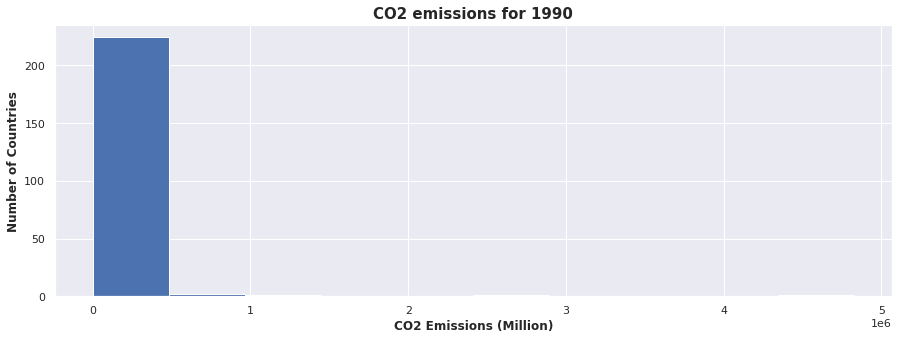

In [27]:
plt.figure(figsize=(15, 5))
plt.hist(co2_emissions[co2_emissions['Year']=='1990']['value'], histtype='barstacked')
plt.title('CO2 emissions for 1990', fontweight='bold', size=15)
plt.xlabel('CO2 Emissions (Million)', fontweight='bold')
plt.ylabel('Number of Countries', fontweight='bold')
plt.show()

Countries mostly emit 500 thousand of CO2 emmisions. It's extremely rare for a country to emit a million CO2 emission. With the information above we determined our data to be right skewed, which is what we have computed with our graph, therefor it's what we expected.

## Calculate the standard deviation and standard error of the mean for CO2 emissions in 1990. How is the standard error different from the standard deviation?

In order to get the standard deviation of the mean for CO2 emissions we need to look at how different the CO2 emissions differ from the mean. This is done by dividing the standard deviation of the original distribution divided by the sample size.

In [28]:
co2_std = np.std(co2_emissions[co2_emissions['Year']=='1990']['value'])
co2_sem = np.std(co2_emissions[co2_emissions['Year']=='1990']['value'], ddof=1) / np.sqrt(np.size(co2_emissions[co2_emissions['Year']=='1990']['value']))

print(f'Standard deviation : {co2_std} \nStandard error of the mean: {co2_sem}')

Standard deviation : 371109.2029339353 
Standard error of the mean: 24577.30736453075


The standard deviation is a measure of how spread out values are around the mean. The standard error which is also called the standard deviation of the means measures the spread of data for the mean of means(a sum of averages divided by the count of the number of averages).

## Create a line graph to show C02 emissions in Brazil, Russia, China, India, the USA and South Africa over time. What does the graph tell you about the difference and change in C02 emissions in these countries?

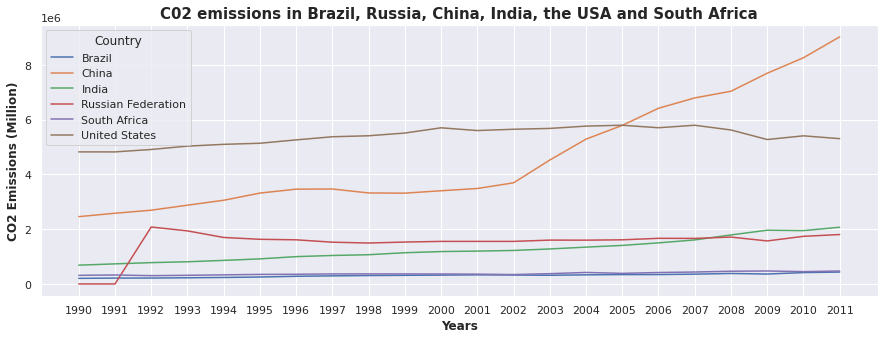

In [29]:
selected_country_omissions = co2_emissions[ (co2_emissions['Country'] == 'Brazil') | (co2_emissions['Country'] == 'Russian Federation') |
(co2_emissions['Country'] == 'China') | (co2_emissions['Country'] == 'India') |
(co2_emissions['Country'] == 'United States') | (co2_emissions['Country'] == 'South Africa')]

plt.figure(figsize=(15, 5))
sns.lineplot(data=selected_country_omissions, x="Year", y= "value", hue="Country")
plt.title('C02 emissions in Brazil, Russia, China, India, the USA and South Africa', fontweight='bold', size=15)
plt.ylabel('CO2 Emissions (Million)', fontweight='bold')
plt.xlabel('Years',fontweight='bold')
plt.show()

The United States starts by having the highest CO2 emissions, then followed by China, which later increases in CO2 emissions becoming the highest producer.

# What is the mean and standard deviation for land area covered by forest in 1990? Why do you think the standard deviation is so large?

In [30]:
land_area_coverage = clean_df[clean_df['SeriesCode']==567]
land_area_cov_1990 = land_area_coverage[land_area_coverage['Year']=='1990']
land_mean = np.mean(land_area_coverage[land_area_coverage['Year']=='1990']['value'])
land_standard_dev = np.std(land_area_coverage[land_area_coverage['Year']=='1990']['value'])

print(f'Land Mean: {land_mean} \nLand Standard Deviation: {land_standard_dev}')

Land Mean: 32.91391304347827 
Land Standard Deviation: 25.052693639629535


To see why the standard deviation is large we'll take a look at the extreme values below:

In [31]:
land_area_cov_1990.sort_values('value' , axis=0, ascending=False, kind='quicksort', na_position='last').head(3)

,CountryCode,Country,SeriesCode,MDG,Series,Year,value
213,254,French Guiana,567,Y,"Proportion of land area covered by forest, per...",1990,99.2
582,740,Suriname,567,Y,"Proportion of land area covered by forest, per...",1990,94.7
390,583,"Micronesia, Federated States of",567,Y,"Proportion of land area covered by forest, per...",1990,91.4


In [32]:
land_area_cov_1990.sort_values('value' , axis=0, ascending=True, kind='quicksort', na_position='last').head(3)

,CountryCode,Country,SeriesCode,MDG,Series,Year,value
198,234,Faeroe Islands,567,Y,"Proportion of land area covered by forest, per...",1990,0.0
201,238,Falkland Islands (Malvinas),567,Y,"Proportion of land area covered by forest, per...",1990,0.0
612,772,Tokelau,567,Y,"Proportion of land area covered by forest, per...",1990,0.0


When we look at the minimum and maximum values of our data one can begin to see the reason for such a difference in size of land mean and land standard deviation. We encounter many countries with 0 land area covered which results in a much lesser mean, through this we paint a picture of why our standard deviation is so large.

# Create histograms for land area covered by forest and percentage of area protected in 1990. Describe the distributions.

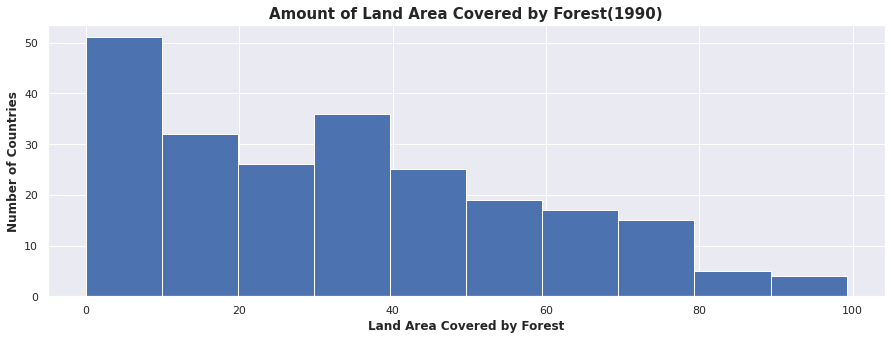

In [33]:
plt.figure(figsize=(15, 5))
plt.hist(land_area_coverage[land_area_coverage['Year'] == '1990']['value'])
plt.title('Amount of Land Area Covered by Forest(1990)', fontweight='bold', size=15)
plt.xlabel('Land Area Covered by Forest',fontweight='bold')
plt.ylabel('Number of Countries',fontweight='bold')
plt.show()

Above is a right skewed distribution. Majority of countries have 10% of the land area covered by forests.

In [34]:
protected_area = clean_df[clean_df['SeriesCode']== 616]

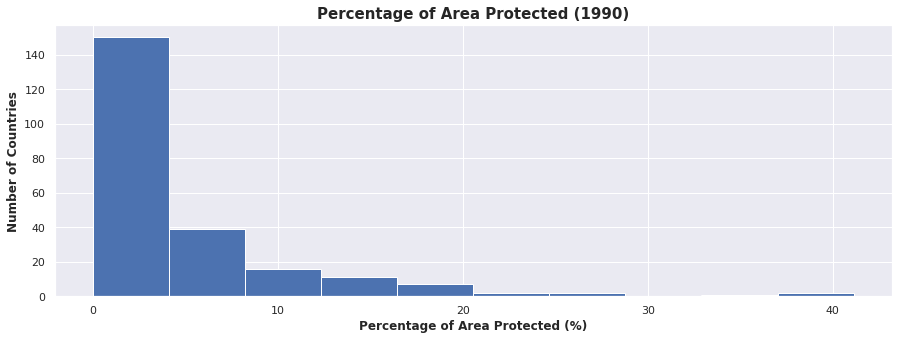

In [35]:
plt.figure(figsize=(15, 5))
plt.hist(protected_area[protected_area['Year'] == '1990']['value'])
plt.title('Percentage of Area Protected (1990)', fontweight='bold', size=15)
plt.xlabel('Percentage of Area Protected (%)',fontweight='bold')
plt.ylabel('Number of Countries',fontweight='bold')
plt.show()

Above is a right skewed distribution. Majority of protected area is below 5%.

# Create a scatterplot with a regression line using seaborn.regplot to show the relationship between the proportion of land area covered by forest and the percentage of area protected in 2000.

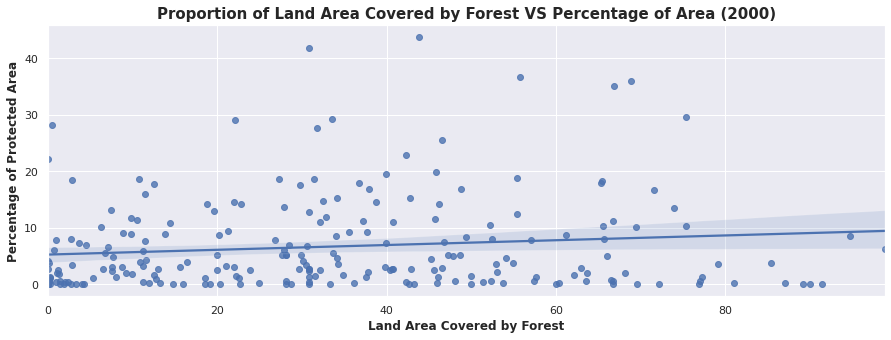

In [36]:
plt.figure(figsize=(15, 5))
ax = sns.regplot(x= land_area_coverage[land_area_coverage['Year']=='2000']['value'], y =protected_area[protected_area['Year']=='2000']['value'])
plt.title('Proportion of Land Area Covered by Forest VS Percentage of Area (2000)', fontweight='bold', size=15)
plt.ylabel('Percentage of Protected Area',fontweight='bold')
plt.xlabel('Land Area Covered by Forest',fontweight='bold')
plt.show()

### What is the relationship between these two variables?
Based of the plot, the relationship between the two variables isn't strong.

### Describe any patterns in the scatterplot.
Most Land Area Coverage has no Protected Area, the variance in our data differs tremendously after the mean Percentage of Protected Area. 

### Do you notice any unusual/extreme values that do not fit the general trend? If you see any unusual values, briefly describe them (Who are they? In what way are they different?).
There are extreme values. Below we look at values that are extreme, we can do this by looking for records where these values exist by getting the countries where the outliers are placed, these values are different because the're far off from the regression line:

In [37]:
clean_df[ 
    ( clean_df['Year'] == '2000' ) & 
    ( clean_df['value'] >= 30 ) & 
    ( clean_df['SeriesCode'] == 616 )
    ]

,CountryCode,Country,SeriesCode,MDG,Series,Year,value
6971,64,Bhutan,616,Y,Terrestrial and marine areas protected to tota...,2000,35.07
7028,344,"China, Hong Kong Special Administrative Region",616,Y,Terrestrial and marine areas protected to tota...,2000,41.84
7247,438,Liechtenstein,616,Y,Terrestrial and marine areas protected to tota...,2000,43.82
7568,862,Venezuela,616,Y,Terrestrial and marine areas protected to tota...,2000,36.67
7586,894,Zambia,616,Y,Terrestrial and marine areas protected to tota...,2000,36.06


## Since neither forested land area nor protected area is normally distributed, we will need to log transform these variables in order to calculate a correlation coefficient. Log transform the variables and show the transformed distributions in a histogram.

In [38]:
np.seterr(divide = 'ignore') 
land_area_log_df = np.log(land_area_coverage.pivot(index = 'Country', columns=['Year'])['value']['1990'])
protected_area_log_df = np.log(protected_area.pivot(index = 'Country', columns=['Year'])['value']['1990'])

land_area_log =  land_area_log_df[np.isfinite(land_area_log_df)]
protected_area_log = protected_area_log_df[np.isfinite(protected_area_log_df)]

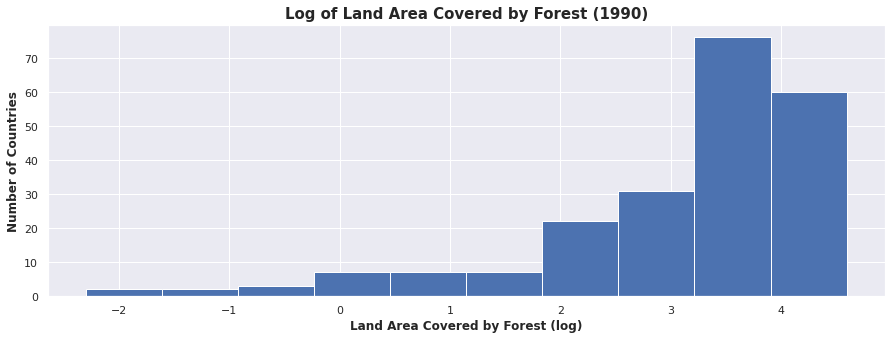

In [39]:
plt.figure(figsize=(15, 5))
land_area_log.hist()
plt.title('Log of Land Area Covered by Forest (1990)', fontweight='bold', size=15)
plt.xlabel('Land Area Covered by Forest (log)',fontweight='bold')
plt.ylabel('Number of Countries',fontweight='bold')
plt.show()

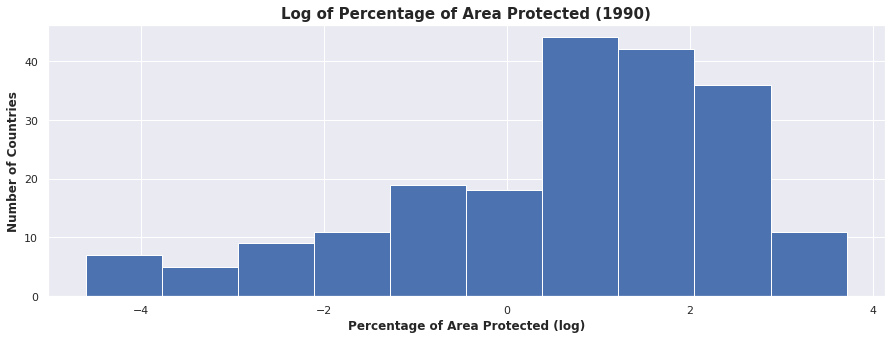

In [40]:
plt.figure(figsize=(15, 5))
protected_area_log.hist()
plt.title('Log of Percentage of Area Protected (1990)', fontweight='bold', size=15)
plt.xlabel('Percentage of Area Protected (log)',fontweight='bold')
plt.ylabel('Number of Countries',fontweight='bold')
plt.show()

The two log plots above are both left skewed after being log transformed.

## Using the pearsonr function from the scipy.stats module, calculate the Pearson correlation coefficient (and its corresponding p value) to determine the nature of the relationship between proportion of land area covered by forest and the percentage of area protected (as measured in 1990 and log transformed). See help(pearsonr) for help on this function.

In [41]:
land_area_log = land_area_log.iloc[:-15]
coef, p = stats.pearsonr(land_area_log, protected_area_log)

print(f'Pearson’s correlation coefficient: {coef} \nP-value: {p}')

Pearson’s correlation coefficient: -0.047625884014049616 
P-value: 0.5009012267127588


## Interpret the size and direction of the correlation statistic.
The greater the absolute value of the correlation coefficient, the stronger the relationship. Please note that the correlation coefficient can only be in ranges -1 to 1, where 1 indicates a strong positive correlation , -1 indicates a strong negative correlation, and where 0 indicates no relationship between two variables.

We received a coefficient of -0.04 because it's a negative it's not enough to say there's no relationship at all, because -0.04 shows a really weak negative correlation. There's only a very weak negative relationship between the variables area-protected and land-area, it's safe to say that when rounded off to the nearest tenth which gives us 0.0 then it may only have no relationship at all.

## Is the relationship statistically significant? Report the appropriate statistic(s) to support your answer.
The significance level is a measure of strength, it's also given the value 0.05 when applying the decisions rule. If p <= 0.05 there's a significant relationship between the variables, else if p > 0.05 there's no significant relationship between the variables.

Our p-value is 0.50, therefore there is no relationship between the variables. Thus we fail to reject the null hypothesis, which states there's no indication of a relationship between variables land area covered by forest and percentage of area protected.

## Calculate the Spearman Rank-Order Correlation Coefficient. This test only looks at the order of the categories, not the values. The Spearman Rank-Order Coefficient is therefore not influenced by non-normality of variables or outliers. How do the results of this test compare the results of the Pearson’s correlation?

In [42]:
coef, p = stats.spearmanr(land_area_log, protected_area_log)
print(f'Spearman Correlation Coefficient: {coef}\nP-value: {p}')

Spearman Correlation Coefficient: -0.046910956726081615
P-value: 0.5073577888342748


The statistical test reports a weak negative correlation with a value of -0.05. The p-value is close to 1, which means that the likelihood that the given samples have no correlation is very likely. The Spearman Rank-Order Correlation Coefficient tests the validity of the Pearson Correlation Coefficient, in this case the two coefficients are close to 0 which indicates randomness.